In [26]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
digits = load_digits()
X = digits.data
y = digits.target

print("Data shape:", X.shape)
print("Number of classes:", len(np.unique(y)))
print("Label distribution:")
print(pd.Series(y).value_counts().sort_index())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Data shape: (1797, 64)
Number of classes: 10
Label distribution:
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64

Training set shape: (1437, 64)
Test set shape: (360, 64)


In [28]:
from sklearn.base import clone

RANDOM_STATE = 42
N_ESTIMATORS = 100

base_tree = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)  # برای AdaBoost/Bagging
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)  # درخت کامل برای مقایسه

bagging_model = BaggingClassifier(
    estimator=clone(base_tree),
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE
)

ada_model = AdaBoostClassifier(
    estimator=clone(base_tree),
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE
)

gb_model = GradientBoostingClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE
)

models = {
    'Decision Tree': dt_model,
    'Bagging': bagging_model,
    'AdaBoost': ada_model,
    'Gradient Boosting': gb_model
}

trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained!\n")

Training Decision Tree...
Decision Tree trained!

Training Bagging...
Bagging trained!

Training AdaBoost...
Bagging trained!

Training AdaBoost...
AdaBoost trained!

Training Gradient Boosting...
AdaBoost trained!

Training Gradient Boosting...
Gradient Boosting trained!

Gradient Boosting trained!



In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {}

for name, model in trained_models.items():
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    results[name] = {
        'Accuracy': acc,
        'Precision (macro)': prec,
        'Recall (macro)': rec,
        'F1-score (macro)': f1
    }

results_df = pd.DataFrame(results).T.round(4)

print("Model evaluation results on the test set (macro-averaged):")
results_df


Model evaluation results on the test set (macro-averaged):


,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
Decision Tree,0.8250,0.8236,0.8242,0.8230
Bagging,0.4278,0.3218,0.4253,0.3201
AdaBoost,0.8306,0.8362,0.8297,0.8284
Gradient Boosting,0.9556,0.9559,0.9552,0.9551


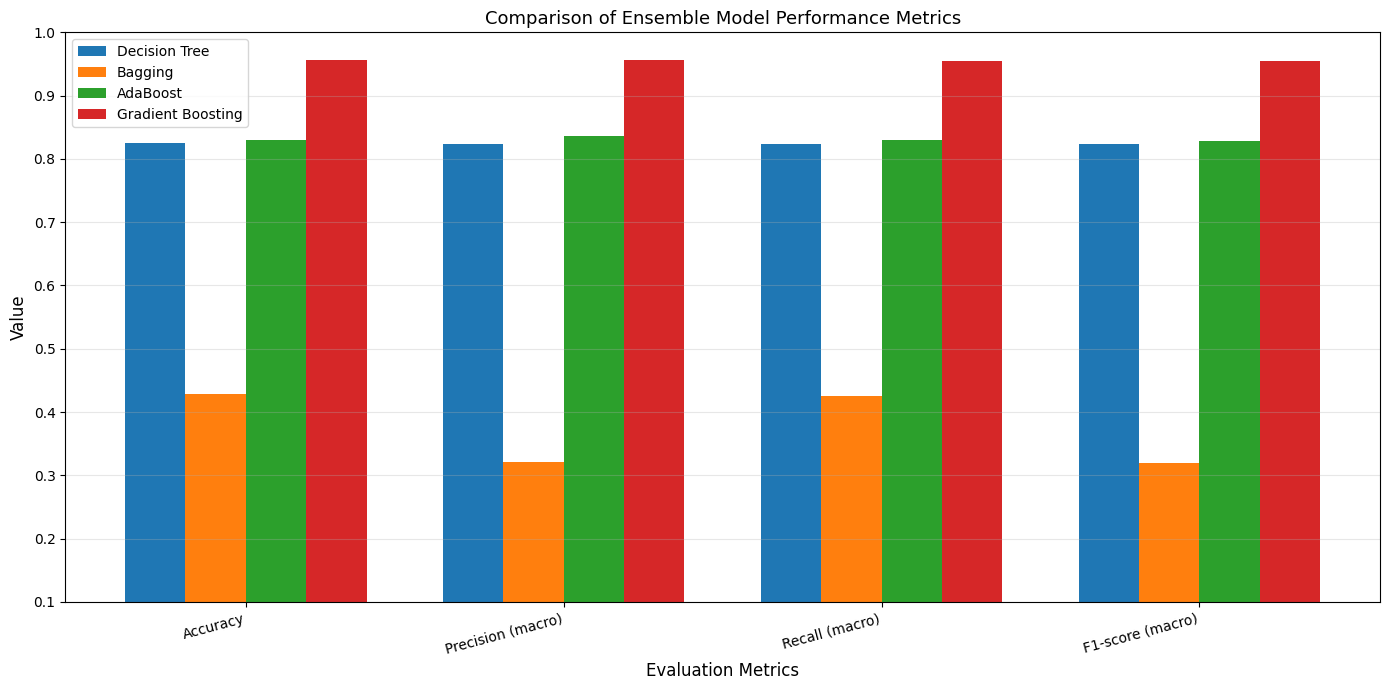


Show 10 sample predictions from Gradient Boosting (best model):


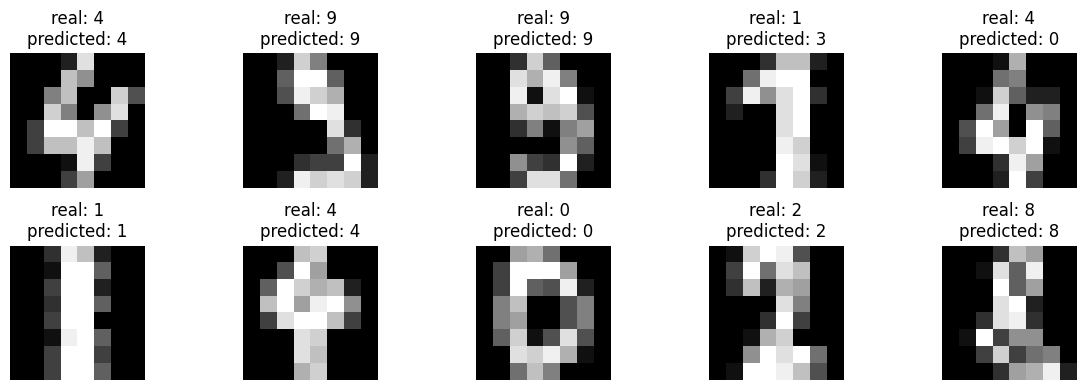


Conclusion:

Best model by F1-score (macro): Gradient Boosting with score 0.9551

Analysis:
- Ensemble models (Bagging, AdaBoost, GBDT) perform noticeably better than a single decision tree.
- Gradient Boosting usually achieves the highest accuracy because it corrects previous errors.
- Bagging reduces variance and AdaBoost focuses on harder examples.
- For medium-sized image data (like digits), GBDT and Random Forest are very effective.


In [30]:

plt.figure(figsize=(14, 7))

metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)']
x = np.arange(len(metrics))
width = 0.19  # slightly reduced to prevent overlap

model_names = list(results.keys())
for i, name in enumerate(model_names):
    scores = results[name]
    plt.bar(x + (i - 1.5) * width, [scores[metric] for metric in metrics], width, label=name)

plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Comparison of Ensemble Model Performance Metrics', fontsize=13)
plt.xticks(x, metrics, rotation=15, ha='right')
plt.legend(fontsize=10)
plt.ylim(0.1, 1.0)  # set y-range to better see differences
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Show 10 sample predictions from Gradient Boosting (best model):")

best_model = trained_models['Gradient Boosting']
y_pred = best_model.predict(X_test)

np.random.seed(42)
indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx].reshape(8, 8), cmap='gray')
    plt.title(f"real: {y_test[idx]}\npredicted: {y_pred[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Conclusion:")
best_f1_model = results_df['F1-score (macro)'].idxmax()
best_f1_score = results_df['F1-score (macro)'].max()
print(f"\nBest model by F1-score (macro): {best_f1_model} with score {best_f1_score:.4f}")

print(f"\nAnalysis:")
print(f"- Ensemble models (Bagging, AdaBoost, GBDT) perform noticeably better than a single decision tree.")
print(f"- Gradient Boosting usually achieves the highest accuracy because it corrects previous errors.")
print(f"- Bagging reduces variance and AdaBoost focuses on harder examples.")
print(f"- For medium-sized image data (like digits), GBDT and Random Forest are very effective.")